# Compute F1 and MAS scores for virus RNA structure predictions
This notebook evaluates structure prediction methods on virus RNA by computing F1 scores and MAS.

## Setup

In [1]:
import os
import re

import numpy as np
import pandas as pd
import seaborn as sns
from Bio import SeqIO
from matplotlib import pyplot as plt
from tqdm import tqdm

import matplotlib as mpl
import matplotlib.font_manager as fm

PREFERRED_FONT = "Arial"

mpl.rcParams["font.family"] = PREFERRED_FONT
mpl.rcParams["font.sans-serif"] = [PREFERRED_FONT]
mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.unicode_minus"] = False

font_prop = fm.FontProperties(family=PREFERRED_FONT)
chosen_font = PREFERRED_FONT


## Auxiliary functions

In [2]:
def split_fasta_seq(seq_str):
    """Split a concatenated sequence+structure string.

    Parameters
    ----------
    seq_str : str
        Raw string from `SeqIO.parse(...).seq`.

    Returns
    -------
    seq : str
        RNA sequence (lowercase, T->U).
    struct : str
        Dot-bracket structure string.
    """
    ind = re.search(r"[.()\[\]{}<>]", seq_str).start()

    seq = seq_str[:ind].lower().replace("t", "u")
    struct = seq_str[ind : ind * 2]

    return seq, struct


def split_prediction_by_reference_length(seq_str, ref_len):
    """Split concatenated prediction into sequence and structure using reference length.

    Parameters
    ----------
    seq_str : str
        Raw concatenated sequence+structure string from `SeqIO.parse(...).seq`.
    ref_len : int
        Reference sequence length.

    Returns
    -------
    seq : str
        RNA sequence (lowercase, T->U).
    struct : str
        Dot-bracket or generalized bracket structure string.
    """
    seq = seq_str[:ref_len].lower().replace("t", "u")
    struct = seq_str[ref_len : ref_len * 2]
    return seq, struct


def write_fasta(fname, seqid, seq, struct):
    """Write a single record (id/seq/struct) to a FASTA-like file."""
    with open(fname, "w") as fin:
        fin.write(f">{seqid}")
        fin.write(f"{seq}")
        fin.write(f"{struct}")


def dot_bracket_to_pairs(structure):
    """Convert dot-bracket notation to base-pair indices.

    Only supports `()` and `.` (pseudoknots are cleaned before scoring).

    Returns
    -------
    pairs : list[tuple[int, int]] | None
        Paired indices `(i, j)` (0-indexed) or `None` if invalid.
    error : str | None
        Error message or `None` on success.
    """
    pairs = []
    stack = []

    for i, char in enumerate(structure):
        if char == "(":
            stack.append(i)
        elif char == ")":
            if not stack:
                return None, f"Unmatched bracket: ')' at position {i + 1}"
            j = stack.pop()
            pairs.append((j, i))
        elif char == ".":
            continue
        else:
            return None, f"Invalid character '{char}' at position {i + 1}"

    if stack:
        return None, f"Unmatched bracket: '(' at position {stack[0] + 1}"

    return pairs, None


def calculate_structure_score(accepted_pairs, predicted_pairs, exact=False):
    """Compute sensitivity and PPV between two base-pair sets."""
    if len(accepted_pairs) == 0:
        sensitivity = 0.0 if len(predicted_pairs) > 0 else 1.0
    else:
        correct_predictions = 0
        for acc_pair in accepted_pairs:
            if exact:
                if acc_pair in predicted_pairs:
                    correct_predictions += 1
            else:
                # Require one endpoint to match exactly and allow ±1 nt at the other endpoint.
                if any(
                    (acc_pair[0] == pred_pair[0] and abs(acc_pair[1] - pred_pair[1]) <= 1) or
                    (acc_pair[1] == pred_pair[1] and abs(acc_pair[0] - pred_pair[0]) <= 1)
                    for pred_pair in predicted_pairs
                ):
                    correct_predictions += 1
        sensitivity = correct_predictions / len(accepted_pairs)

    if len(predicted_pairs) == 0:
        ppv = 0.0 if len(accepted_pairs) > 0 else 1.0
    else:
        correct_in_predicted = 0
        for pred_pair in predicted_pairs:
            if exact:
                if pred_pair in accepted_pairs:
                    correct_in_predicted += 1
            else:
                if any(
                    (acc_pair[0] == pred_pair[0] and abs(acc_pair[1] - pred_pair[1]) <= 1) or
                    (acc_pair[1] == pred_pair[1] and abs(acc_pair[0] - pred_pair[0]) <= 1)
                    for acc_pair in accepted_pairs
                ):
                    correct_in_predicted += 1
        ppv = correct_in_predicted / len(predicted_pairs)

    return sensitivity, ppv


def scorer(reference_struct, prediction_struct, seq_id="", method=""):
    """Score a predicted structure against a reference (sensitivity, PPV, F1)."""
    if len(reference_struct) != len(prediction_struct):
        print(
            f"Warning: structure length mismatch: ID={seq_id}, method={method} "
            f"(ref={len(reference_struct)}, pred={len(prediction_struct)})"
        )
        return 0.0, 0.0, 0.0

    ref_pairs, ref_error = dot_bracket_to_pairs(reference_struct)
    if ref_error:
        print(f"Error: failed to parse reference structure: ID={seq_id}, method={method}")
        print(f"  {ref_error}")
        return 0.0, 0.0, 0.0

    pred_pairs, pred_error = dot_bracket_to_pairs(prediction_struct)
    if pred_error:
        print(f"Error: failed to parse predicted structure: ID={seq_id}, method={method}")
        print(f"  {pred_error}")
        return 0.0, 0.0, 0.0

    sensitivity, ppv = calculate_structure_score(ref_pairs, pred_pairs, exact=False)

    f1 = 0.0
    if sensitivity + ppv > 0:
        f1 = 2 * sensitivity * ppv / (sensitivity + ppv)

    return sensitivity, ppv, f1


## Mean absolute similarity (MAS) score and probing normalization

In [3]:
def mas_score(pred, nscores, tol=0.1):
    """Mean absolute similarity (MAS) between a binary prediction and probing scores.

    Parameters
    ----------
    pred : array-like of int
        Per-nucleotide paired/unpaired prediction in {0, 1}.
    nscores : array-like of float
        Per-nucleotide probing scores in [0, 1].
    tol : float
        Nucleotides with scores within (0.5 - tol/2, 0.5 + tol/2) are ignored.

    Returns
    -------
    MASp, MASu, MAS : float
        Paired MAS, unpaired MAS, and overall MAS.
    """
    pred = np.asarray(pred, dtype=float)
    nscores = np.asarray(nscores, dtype=float)

    i_paired = nscores < 0.5 - tol / 2
    i_unpaired = nscores >= 0.5 + tol / 2

    diff = pred - nscores

    mas_pos = 1 - np.absolute(diff[i_paired]).mean()
    mas_neg = 1 - np.absolute(diff[i_unpaired]).mean()

    ref_ideal = np.ones((len(nscores),))
    ref_ideal[nscores < tol / 2 + 0.5] = 0.0

    diff_ideal = ref_ideal - nscores
    diff_worst = (1 - ref_ideal) - nscores

    max_mas_pos = 1 - np.absolute(diff_ideal[i_paired]).mean()
    max_mas_neg = 1 - np.absolute(diff_ideal[i_unpaired]).mean()
    min_mas_pos = 1 - np.absolute(diff_worst[i_paired]).mean()
    min_mas_neg = 1 - np.absolute(diff_worst[i_unpaired]).mean()

    MASp = (mas_pos - min_mas_pos) / (max_mas_pos - min_mas_pos)
    MASu = (mas_neg - min_mas_neg) / (max_mas_neg - min_mas_neg)

    ave_mas = 1 - np.absolute(diff[i_paired | i_unpaired]).mean()

    max_ave_mas = 1 - np.absolute(diff_ideal[i_paired | i_unpaired]).mean()
    min_ave_mas = 1 - np.absolute(diff_worst[i_paired | i_unpaired]).mean()
    MAS = (ave_mas - min_ave_mas) / (max_ave_mas - min_ave_mas)

    return MASp, MASu, MAS


## Prepare dataset and predictions

In [4]:
viruses_fasta = "../data/viruses.fasta"

VIRUS_ID_ORDER = [
    "IAV-NS", "IAV-M", "IAV-NA", "IAV-NP", "IAV-HA", "IAV-PA", "IAV-PB1", "IAV-PB2",
    "TBSV-T100", "HIV-1-NL4-3", "SIVmac239", "HCV-1b-Con1", "HCV-2a-Jc1", "HCV-2a-JFH1",
    "DENV1-EDEN2402", "DENV2-EDEN3295", "DENV3-EDEN863", "DENV4-EDEN2270",
    "ZIKV-Singapore", "ZIKV-Brazil", "ZIKV-African", "ZIKV-FrenchPolynesia", "ZIKV-Asian",
    "VEEV-ZPC738", "SINV-Girdwood", "CHIKV-StMartin", "PEDV-AJ1102", "SARS-CoV-2",
]
VIRUS_TO_ID = {f"virus{i}": vid for i, vid in enumerate(VIRUS_ID_ORDER, start=1)}


def to_rna_id(name):
    return VIRUS_TO_ID.get(name, name)


viruses = {}
for rec in SeqIO.parse(viruses_fasta, "fasta"):
    viruses[to_rna_id(rec.id)] = split_fasta_seq(str(rec.seq))

probing_scores_raw = pd.read_csv("../data/probing_scores.csv", index_col=0)

probing_scores = {}
for rna_id in probing_scores_raw.index:
    scores = probing_scores_raw.loc[rna_id].dropna().values
    scores[scores < 0] = 0.5
    scores[scores > 1] = 1
    probing_scores[to_rna_id(rna_id)] = scores

print(f"Loaded probing scores for {len(probing_scores)} RNAs")
print(f"Loaded reference structures for {len(viruses)} RNAs")


Loaded probing scores for 28 RNAs
Loaded reference structures for 28 RNAs


In [5]:
methods = [
    "CONTRAfold",
    "CENTROIDFOLD",
    "ProbKnot",
    "ShapeKnots",
    "RNAstructure",
    "RNAfold",
    "pKiss",
    "RNAshapes",
    "LinearFold",
    "SPOT-RNA",
    "LinearPartition",
    "rna-state-inf",
    "MXfold2",
    "RNA-FM",
    "KnotFold",
    "RFold",
    "BPfold",
    "RiNALMo",
    "EternaFold",
    "ERNIE-RNA"
]

predictions = {}
for method in methods:
    predictions[method] = {}
    prediction_fasta = f"../predict_results/{method}.fasta"

    if not os.path.isfile(prediction_fasta):
        print(f"Warning: missing prediction file: {prediction_fasta} (skipping)")
        continue

    for rec in SeqIO.parse(prediction_fasta, "fasta"):
        ref_len = len(viruses[rec.id][0])
        _, struct = split_prediction_by_reference_length(str(rec.seq), ref_len)
        predictions[method][rec.id] = struct


## Compute global metrics
Compare the predictions with references of each virus. The references includes the dot-bracket structure and the structural probing score

In [6]:
results_file = "results_virus_scores.xlsx"

if os.path.isfile(results_file):
    print(f"Loading cached results from: {results_file}")
    results = pd.read_excel(results_file)
    print(f"  Loaded {len(results)} rows")
else:
    print("No cached results found; computing scores...")

    rows = []
    for method in tqdm(methods):
        for rna_id in predictions[method]:
            struct_reference = viruses[rna_id][1]
            struct = predictions[method][rna_id]

            pairing_prediction = np.array([1 if n == "." else 0 for n in struct], dtype=float)

            MASp, MASu, MAS = np.nan, np.nan, np.nan
            if rna_id in probing_scores:
                try:
                    MASp, MASu, MAS = mas_score(pairing_prediction, probing_scores[rna_id])
                except Exception as e:
                    print(f"MAS computation failed: method={method}, ID={rna_id}: {e}")

            # Drop pseudoknot bracket types for F1 evaluation (keep only '.', '(', ')').
            struct_clean = struct
            for c in np.unique(list(struct)):
                if c not in ["(", ")", "."]:
                    struct_clean = struct_clean.replace(c, ".")

            struct_ref_clean = struct_reference
            for c in np.unique(list(struct_reference)):
                if c not in ["(", ")", "."]:
                    struct_ref_clean = struct_ref_clean.replace(c, ".")

            s, p, f1 = scorer(struct_ref_clean, struct_clean, seq_id=rna_id, method=method)

            rows.append([rna_id, method, struct, MASp, MASu, MAS, s, p, f1])

    results = pd.DataFrame(
        rows,
        columns=[
            "ID",
            "Method",
            "Struct",
            "MASp",
            "MASu",
            "MAS",
            "Sensitivity",
            "Precision",
            "F1",
        ],
    )

    results.to_excel(results_file, index=False)
    print(f"Saved results to: {results_file}")

Loading cached results from: results_virus_scores.xlsx
  Loaded 321 rows


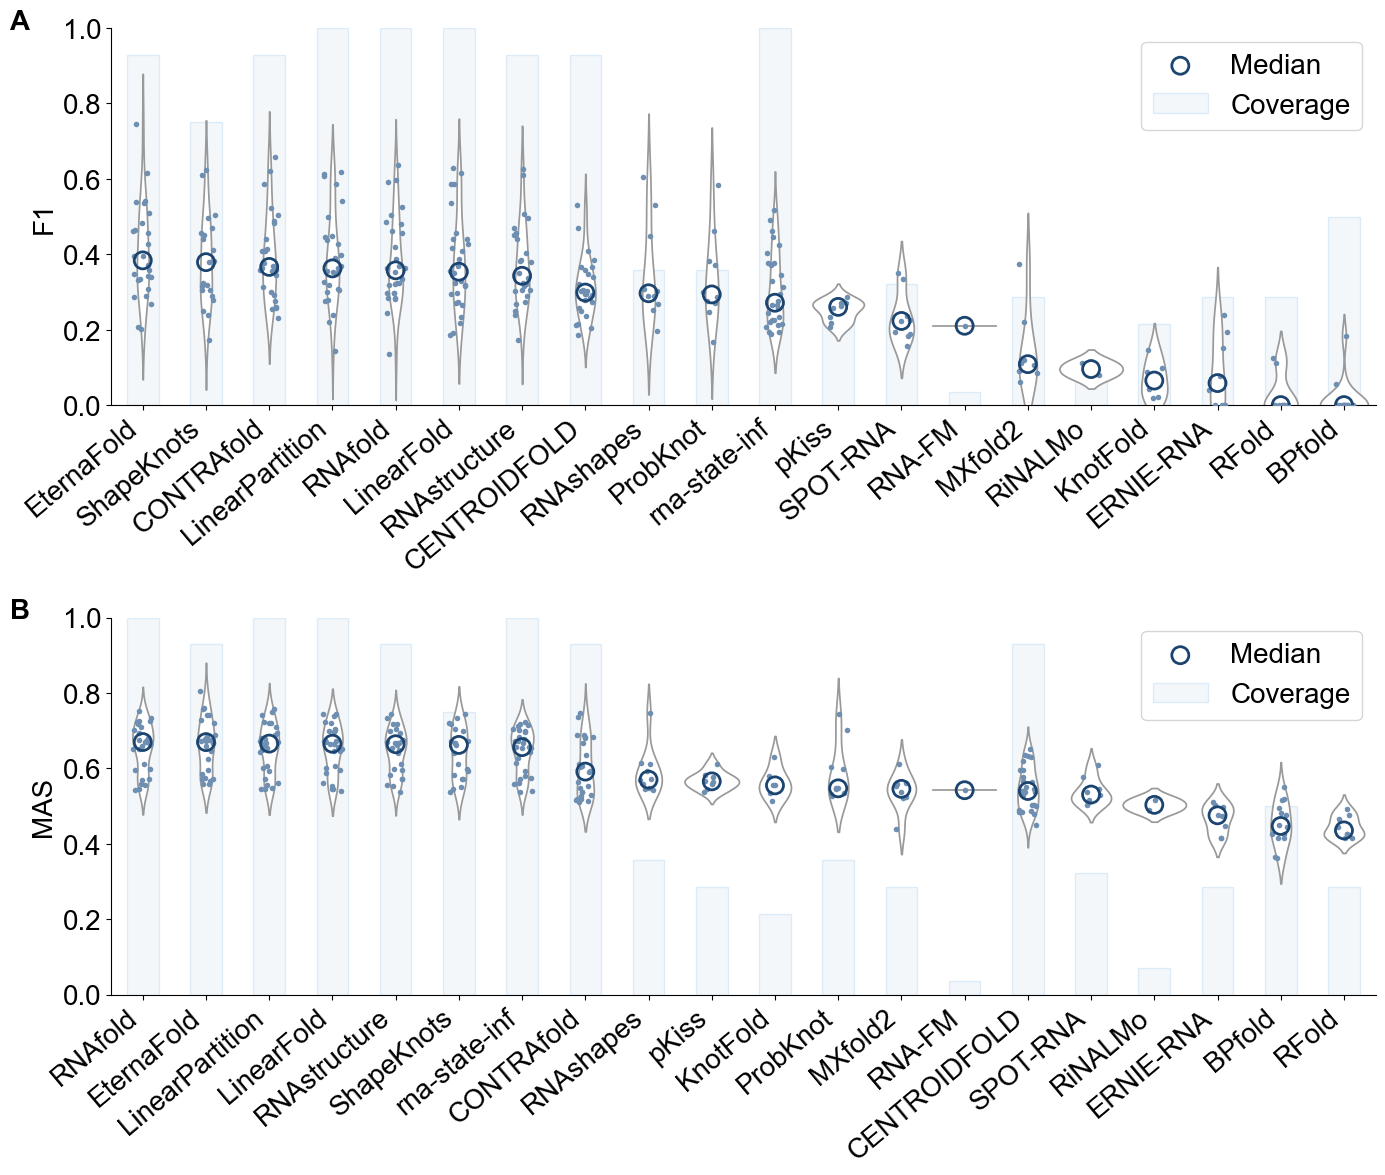

In [7]:
os.makedirs("fig", exist_ok=True)

legend_font = fm.FontProperties(family=PREFERRED_FONT, size=20)

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

coverage_dict = dict(
    zip(
        results.groupby("Method", sort=False)["F1"].count().index,
        results.groupby("Method", sort=False)["F1"].count().values / len(results.ID.unique()),
    )
)

for panel_label, ax, metric in zip(["A", "B"], axes, ["F1", "MAS"]):
    ax.text(
        -0.08,
        1.05,
        panel_label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        color="black",
        va="top",
        ha="left",
    )

    metric_median = results.groupby(by="Method", sort=False)[metric].median()
    method_order = metric_median.sort_values(ascending=False).index.tolist()
    coverage_ordered = [coverage_dict.get(m, 0) for m in method_order]

    ax.bar(
        np.arange(len(coverage_ordered)),
        coverage_ordered,
        color="#F4F7FA",
        edgecolor=(0.4, 0.7, 0.9, 0.2),
        width=0.5,
        label="Coverage",
    )

    sns.violinplot(
        data=results,
        x="Method",
        y=metric,
        width=1,
        inner=None,
        color="white",
        ax=ax,
        order=method_order,
    )

    metric_median_ordered = metric_median[method_order]
    ax.scatter(
        x=range(len(metric_median_ordered)),
        y=metric_median_ordered,
        marker="o",
        facecolors="none",
        edgecolors="#1B4470",
        s=150,
        linewidth=2,
        zorder=10,
        label="Median",
    )

    sns.stripplot(
        data=results,
        x="Method",
        y=metric,
        color="#6E8FB2",
        size=4,
        jitter=0.15,
        ax=ax,
        order=method_order,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim([0, 1])
    ax.legend(prop=legend_font, labelcolor="black")
    ax.set_xlabel("", fontsize=20, color="black")
    ax.set_ylabel(metric, fontsize=20, color="black")
    ax.set_xticks(range(len(method_order)))
    ax.set_xticklabels(method_order, rotation=40, ha="right", fontsize=20, color="black")
    ax.tick_params(axis="y", labelsize=20, labelcolor="black")

plt.tight_layout()
plt.savefig("fig/F1_MAS_distribution_by_method.pdf", format="pdf", bbox_inches="tight", dpi=350)
plt.show()
